In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

pd.options.display.float_format = '{:.4f}'.format

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from typing import List

import polars as pl

def get_ozon_link(ids):
    for el in ids:
        print(f'https://www.ozon.ru/product/{el}')

In [ ]:
get_ozon_link([148481523, 398644623, 145923184])

https://www.ozon.ru/product/148481523
https://www.ozon.ru/product/398644623
https://www.ozon.ru/product/145923184


In [ ]:
product_info = pl.read_parquet('/content/drive/MyDrive/recsys/data/product_information_full')
product_info.head()

product_id,name,brand,type,category_id,category_name
i64,str,str,str,i32,str
160839072,"""CeraVe Смягчающий крем для сух…","""CeraVe""","""Гель для ухода за кожей""",38,"""Сыворотки для лица"""
161689127,"""Yves Rocher / Ив Роше / Увлажн…","""Yves Rocher France""","""Гель для ухода за кожей""",38,"""Сыворотки для лица"""
221508445,"""Bioderma Эликсир для ухода за …","""Bioderma""","""Эликсир для ухода за кожей""",38,"""Сыворотки для лица"""
309017861,"""ART&FACT. / Сыворотка для лица…","""ART&FACT.""","""Сыворотка для лица""",38,"""Сыворотки для лица"""
793710195,"""Breylee Сыворотка для лица Ант…","""Breylee""","""Сыворотка для лица""",38,"""Сыворотки для лица"""


In [ ]:
user_actions = pl.read_parquet('/content/drive/MyDrive/recsys/data/filtered_user_actions_top5000.parquet')
user_actions.head()

user_id,product_id,date,action_type,period,category_name,choice_level,action_w
i32,i64,date,str,date,str,f64,i64
2102996,322819992,2024-07-29,"""click""",2024-07-01,"""Томатная паста, кетчуп""",0.359168,1
5240641,356541992,2024-05-16,"""to_cart""",2024-05-01,"""Плавленый""",0.477305,3
2346229,142224890,2024-03-18,"""favorite""",2024-03-01,"""Овощи""",0.523775,2
2346229,303734515,2024-04-19,"""click""",2024-04-01,"""0-2,5%""",0.414519,1
2346229,554527729,2024-05-02,"""click""",2024-05-01,"""Арбузы, дыни""",0.339376,1


## EDA и подготовка данных

In [ ]:
user_actions = user_actions.with_columns(
    pl.col("date").dt.truncate("1mo").alias("period")
).filter(pl.col("period") >= pl.date(2024, 3, 1))

In [ ]:
user_actions.shape

(178615795, 4)

In [ ]:
product_info.shape

(238443, 6)

In [ ]:
user_actions.select([
    pl.col("user_id").n_unique(),
    pl.col("product_id").n_unique()
])

user_id,product_id
u32,u32
5224053,374820


In [ ]:
(
    user_actions
    .group_by("period")
    .len()
    .sort("period")
)

period,len
date,u32
2024-03-01,37127367
2024-04-01,32885415
2024-05-01,34563802
2024-06-01,36350494
2024-07-01,37620220


In [ ]:
# удалим пакеты
user_actions = (user_actions
    .filter(pl.col('product_id') != 519413018)
    .filter(pl.col('product_id') != 576985723)
)

In [ ]:
stats = (
    user_actions
    .group_by(["period", "action_type"])
    .len()
    .pivot(
        values="len",
        index="period",
        columns="action_type"
    )
    .sort("period")
)

stats = stats.with_columns(
    (pl.col("to_cart") / pl.col("click")).alias("ctr_to_cart")
)

stats = stats.with_columns(
    (pl.col("order") / pl.col("to_cart")).alias("conv_order_from_cart")
)

stats = stats.with_columns(
    (pl.col("order") / pl.col("click")).alias("conv_order_from_click")
)

stats = stats.with_columns(
    (pl.col("favorite") / pl.col("click")).alias("fav_rate")
)

stats

/tmp/ipykernel_2481/1551245989.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


period,click,order,to_cart,favorite,ctr_to_cart,conv_order_from_cart,conv_order_from_click,fav_rate
date,u32,u32,u32,u32,f64,f64,f64,f64
2024-03-01,15075731,3738089,17396743,903563,1.153957,0.214873,0.247954,0.059935
2024-04-01,13060139,3382602,15614495,815730,1.195584,0.216632,0.259002,0.06246
2024-05-01,13157924,4503490,16093135,794560,1.223076,0.279839,0.342264,0.060386
2024-06-01,12539372,7963077,15086422,744930,1.203124,0.527831,0.635046,0.059407
2024-07-01,13102910,8253307,15441457,804124,1.178475,0.53449,0.629884,0.06137


to_cart — самый частый тип действий (15–17 млн)

click — сопоставим по масштабу (12–15 млн)

order — существенно реже (3–8 млн)

favorite — редкий сигнал (0.7–0.9 млн)

пользователи могут добавлять в корзину без открытия карточки

происходит резкий сдвиг в количестве покупок



In [ ]:
(
    user_actions
    .group_by("period")
    .agg(
        pl.col("user_id").n_unique().alias("n_users")
    )
    .sort("period")
)

period,n_users
date,u32
2024-03-01,2044284
2024-04-01,1842322
2024-05-01,1791937
2024-06-01,1734503
2024-07-01,1874955


Падение аудитории
март → июнь: −15% пользователей

рост order происходит на фоне падения users

In [ ]:
(
    user_actions
    .select(["user_id", "period"])
    .unique()
    .group_by("user_id")
    .agg(
        pl.col("period").n_unique().alias("active_months")
    )
    .group_by("active_months")
    .len()
    .sort("active_months")
)

active_months,len
u32,u32
1,3186782
2,967849
3,447508
4,278248
5,342001


Наблюдается отток аудитории, для них нет стабильности и истории. Удалим тех, кто активен только 1 месяц

In [ ]:
user_activity = (
    user_actions
    .select(["user_id", "period"])
    .unique()
    .group_by("user_id")
    .agg(
        pl.col("period").n_unique().alias("active_months")
    )
    .filter(
    pl.col("active_months") >= 2
)
)

In [ ]:
user_activity.head()

user_id,active_months
i32,u32
5687308,2
1022963,3
9532539,2
5554256,2
867102,3


In [ ]:
user_actions = user_actions.join(
    user_activity.select("user_id"),
    on="user_id",
    how="inner"
)

In [ ]:
user_actions.head()

user_id,product_id,date,action_type,period
i32,i64,date,str,date
10542465,166798937,2024-04-03,"""to_cart""",2024-04-01
1423743,180730425,2024-05-11,"""to_cart""",2024-05-01
2102996,322819992,2024-07-29,"""click""",2024-07-01
2569829,25343359,2024-06-05,"""order""",2024-06-01
10498283,171803041,2024-06-02,"""order""",2024-06-01


In [ ]:
(
    user_actions
    .group_by("period")
    .agg(
        pl.col("user_id").n_unique().alias("n_users")
    )
    .sort("period")
)

period,n_users
date,u32
2024-03-01,1265783
2024-04-01,1234927
2024-05-01,1238410
2024-06-01,1187431
2024-07-01,1174668


In [ ]:
stats = (
    user_actions
    .group_by(["period", "action_type"])
    .len()
    .pivot(
        values="len",
        index="period",
        columns="action_type"
    )
    .sort("period")
)

stats = stats.with_columns(
    (pl.col("to_cart") / pl.col("click")).alias("ctr_to_cart")
)

stats = stats.with_columns(
    (pl.col("order") / pl.col("to_cart")).alias("conv_order_from_cart")
)

stats = stats.with_columns(
    (pl.col("order") / pl.col("click")).alias("conv_order_from_click")
)

stats = stats.with_columns(
    (pl.col("favorite") / pl.col("click")).alias("fav_rate")
)

stats

/tmp/ipykernel_2481/1551245989.py:5: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


period,to_cart,favorite,click,order,ctr_to_cart,conv_order_from_cart,conv_order_from_click,fav_rate
date,u32,u32,u32,u32,f64,f64,f64,f64
2024-03-01,16324103,740993,13152532,3543437,1.241138,0.217068,0.269411,0.056338
2024-04-01,14911030,682915,11720449,3255895,1.272223,0.218355,0.277796,0.058267
2024-05-01,15341957,670751,11917935,4333163,1.2873,0.282439,0.363583,0.056281
2024-06-01,14422947,628667,11330450,7696160,1.272937,0.533605,0.679246,0.055485
2024-07-01,14188396,630026,11306806,7751468,1.254854,0.546324,0.685558,0.055721


click → взаимодействие / интерес

to_cart → выраженное намерение

order → реализация намерения

favorite → отложенный интерес

## Что считать мнением?

Мнение пользователя = его стабильные предпочтения

То есть:
какие типы товаров он чаще всего смотрит, добавляет в корзину и покупает

Поведенческий след предпочтений

Важно отделять предпочтение и неизбежный спрос

например, Хлеб, молоко, вода
покупаются регулярно почти всеми
это базовая потребность

Кроме того, есть товары, которые условно отражают мнение пользователей, а есть те, которые нет. И здесь нельзя просто выкинуть популярные товары, так как они тоже могут нести информацию о мнении. Нужно посмотреть, насколько внутри категорий люди склонны выбирать разное.

In [ ]:
orders = (
    user_actions
    .filter(pl.col("action_type") == "order")
    .join(
        product_info.select(["product_id", "category_id", "category_name"]),
        on="product_id",
        how="left"
    )
)

In [ ]:
orders

user_id,product_id,date,action_type,period,category_id,category_name
i32,i64,date,str,date,i32,str
2569829,25343359,2024-06-05,"""order""",2024-06-01,655,"""Тампоны"""
10498283,171803041,2024-06-02,"""order""",2024-06-01,674,"""Печенье"""
8368519,933027806,2024-06-21,"""order""",2024-06-01,399,"""Туалетная бумага"""
10691321,679778603,2024-06-27,"""order""",2024-06-01,578,"""Семейное"""
2062459,263792927,2024-06-28,"""order""",2024-06-01,333,"""Твердое"""
…,…,…,…,…,…,…
5219201,383982855,2024-06-10,"""order""",2024-06-01,418,"""Сэндвичи, роллы"""
10681062,149086710,2024-05-08,"""order""",2024-05-01,881,"""Полоскание и уход"""
415136,145923184,2024-04-06,"""order""",2024-04-01,821,"""Сливочное"""


In [ ]:
cat_prod = (
    orders
    .group_by(["category_name", "product_id"])
    .len()
    .rename({"len": "cnt"})
)
cat_prod

category_name,product_id,cnt
str,i64,u32
"""Игрушки""",147959178,72
"""Накладные наушники""",360549112,49
"""Сосиски""",1577476497,638
"""Офисная бумага и фотобумага""",1461280057,1
"""Вторые блюда""",590396358,36
…,…,…
"""Тесто, хлеб, выпечка""",1502131089,123
null,1125185531,1
"""Принтеры и МФУ""",1555211050,1


In [ ]:
cat_prod = cat_prod.with_columns(
    (pl.col("cnt") / pl.col("cnt").sum().over("category_name"))
    .alias("share")
)
cat_prod

category_name,product_id,cnt,share
str,i64,u32,f64
"""Игрушки""",147959178,72,0.012601
"""Накладные наушники""",360549112,49,0.0245
"""Сосиски""",1577476497,638,0.002857
"""Офисная бумага и фотобумага""",1461280057,1,0.000131
"""Вторые блюда""",590396358,36,0.000183
…,…,…,…
"""Тесто, хлеб, выпечка""",1502131089,123,0.001952
null,1125185531,1,0.00004
"""Принтеры и МФУ""",1555211050,1,0.003861


Энтропия категории =
насколько разнообразно люди покупают товары внутри этой категории

Посчитаем энтропию

In [ ]:
cat_choice = (
    cat_prod
    .with_columns(
        (-pl.col("share") * pl.col("share").log()).alias("entropy_part")
    )
    .group_by("category_name")
    .agg(
        pl.col("entropy_part").sum().alias("entropy"),
        pl.col("product_id").n_unique().alias("n_products"),
        pl.col("cnt").sum().alias("total_orders")
    )
)
cat_choice

category_name,entropy,n_products,total_orders
str,f64,u32,u32
"""Рассольный, копченый""",3.646419,108,173164
"""Тампоны""",2.344461,72,18624
"""Свинина""",3.950232,204,123995
"""Мыши и трекпады""",2.647923,34,1340
"""Увлажнение и питание""",4.029751,201,28980
…,…,…,…
"""Чехлы для наушников""",-0.0,1,3
"""Насадки и средства для очистки""",1.302373,8,253
"""Зонты и дождевики""",1.706352,21,1646


Отнормируем

In [ ]:
cat_choice = cat_choice.with_columns(
    (pl.col("entropy") / pl.col("entropy").max())
    .alias("choice_level")
)

In [ ]:
cat_choice

category_name,entropy,n_products,total_orders,choice_level
str,f64,u32,u32,f64
"""Теплый свет""",0.192626,3,51,0.026724
"""Кувшины""",2.050122,33,3407,0.284421
"""Кефир, ряженка""",3.411226,131,208713,0.473252
"""От вредных привычек""",2.419726,19,3325,0.335697
"""Треки и парковки""",1.677927,23,171,0.232785
…,…,…,…,…
"""Наушники-вкладыши""",5.18476,460,12622,0.719301
"""Посудомоечные машины""",-0.0,1,2,-0.0
"""Сменные картриджи""",2.694704,156,6872,0.373846


Теперь мы получили информацию, насколько у пользователей есть выбор внутри категории

Оставим только информативные категории

<Axes: ylabel='Count'>

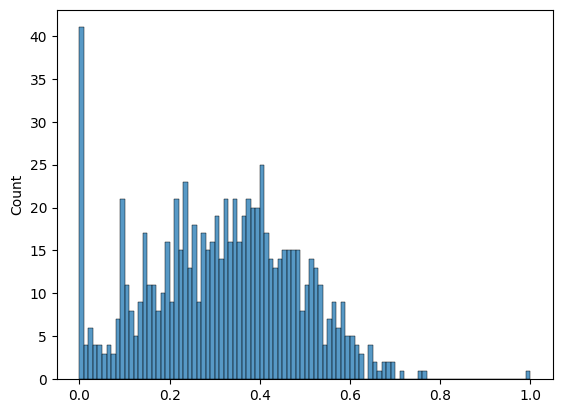

In [ ]:
sns.histplot(cat_choice['choice_level'], bins=100)

In [ ]:
threshold = 0.2

In [ ]:
cat_choice = cat_choice.filter(pl.col('choice_level') >= 0.2)

In [ ]:
product_info = product_info.join(
    cat_choice,
    on="category_name",
    how="inner"
)

In [ ]:
product_info

product_id,name,brand,type,category_id,category_name,entropy,n_products,total_orders,choice_level
i64,str,str,str,i32,str,f64,u32,u32,f64
160839072,"""CeraVe Смягчающий крем для сух…","""CeraVe""","""Гель для ухода за кожей""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973
161689127,"""Yves Rocher / Ив Роше / Увлажн…","""Yves Rocher France""","""Гель для ухода за кожей""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973
221508445,"""Bioderma Эликсир для ухода за …","""Bioderma""","""Эликсир для ухода за кожей""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973
309017861,"""ART&FACT. / Сыворотка для лица…","""ART&FACT.""","""Сыворотка для лица""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973
793710195,"""Breylee Сыворотка для лица Ант…","""Breylee""","""Сыворотка для лица""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973
…,…,…,…,…,…,…,…,…,…
1154315599,"""Сушилка для овощей и фруктов 3…","""Великие реки""","""Дегидратор""",284,"""Сушилки для овощей""",3.217285,46,121,0.446346
1196912369,"""GFGRIL Электрическая сушилка д…","""GFGRIL""","""Дегидратор""",284,"""Сушилки для овощей""",3.217285,46,121,0.446346
1255681315,"""Дегидратор сушилка для овощей …","""Marta""","""Дегидратор""",284,"""Сушилки для овощей""",3.217285,46,121,0.446346


In [ ]:
user_actions

user_id,product_id,date,action_type,period
i32,i64,date,str,date
10542465,166798937,2024-04-03,"""to_cart""",2024-04-01
1423743,180730425,2024-05-11,"""to_cart""",2024-05-01
2102996,322819992,2024-07-29,"""click""",2024-07-01
2569829,25343359,2024-06-05,"""order""",2024-06-01
10498283,171803041,2024-06-02,"""order""",2024-06-01
…,…,…,…,…
1065296,871513673,2024-05-11,"""order""",2024-05-01
10655608,172793428,2024-04-09,"""click""",2024-04-01
8142373,316742407,2024-05-23,"""click""",2024-05-01


Учтём, что что-то покупают редко, а что-то часто

In [ ]:
item_popularity = (
    user_actions
    .filter(pl.col("action_type") == "order")
    .group_by("product_id")
    .len()
    .rename({"len": "item_freq"})
)

In [ ]:
item_popularity = item_popularity.with_columns(
    pl.col("item_freq").log1p().alias("item_popularity")
)

In [ ]:
product_info = product_info.join(
    item_popularity,
    on="product_id",
    how="inner"
)
product_info

product_id,name,brand,type,category_id,category_name,entropy,n_products,total_orders,choice_level,item_freq,item_popularity
i64,str,str,str,i32,str,f64,u32,u32,f64,u32,f64
221508445,"""Bioderma Эликсир для ухода за …","""Bioderma""","""Эликсир для ухода за кожей""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973,2,1.098612
896995061,"""Uriage Барьедерм-цика крем с м…","""Uriage""","""Сыворотка для лица""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973,5,1.791759
1533809262,"""Holika Holika Универсальный не…","""Holika Holika""","""Гель для ухода за кожей""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973,1,0.693147
150153816,"""Сыворотка для лица с молочной …","""Levrana""","""Сыворотка для лица""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973,22,3.135494
296411498,"""MARY&MAY Сыворотка для лица с …","""MARY&MAY""","""Сыворотка для лица""",38,"""Сыворотки для лица""",3.200187,112,4361,0.443973,2,1.098612
…,…,…,…,…,…,…,…,…,…,…,…
693146711,"""Дегидратор сушилка для овощей …","""Marta""","""Дегидратор""",284,"""Сушилки для овощей""",3.217285,46,121,0.446346,2,1.098612
1339453573,"""Сушилка для овощей и фруктов G…","""GARLYN""","""Дегидратор""",284,"""Сушилки для овощей""",3.217285,46,121,0.446346,1,0.693147
1424062245,"""Сушилка для зелени и салата FA…","""Fackelmann""","""Сушилка для салата/овощей/фрук…",284,"""Сушилки для овощей""",3.217285,46,121,0.446346,1,0.693147


<Axes: ylabel='Count'>

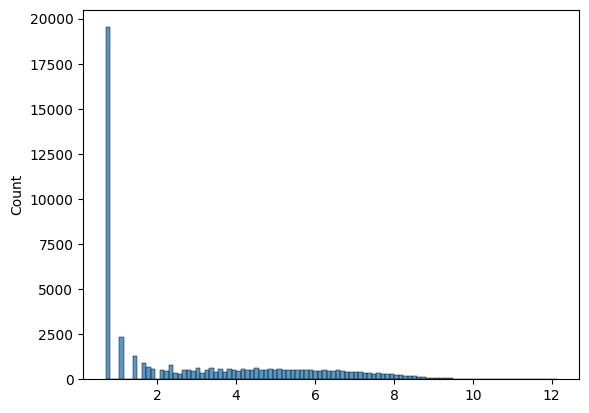

In [ ]:
sns.histplot(product_info['item_popularity'], bins=100)

power-law / long tail distribution

нет явного мнения (как рейтинг/отзыв).

мнение = насколько пользователь тянется к категории/товару в условиях выбора

In [ ]:
action_weight = {
    "click": 1,
    "to_cart": 3,
    "order": 5,
    "favorite": 2
}

In [ ]:
user_actions = user_actions.join(
    product_info.select(["product_id", "category_name", "choice_level"]),
    on="product_id",
    how="inner"
)

In [ ]:
user_actions

user_id,product_id,date,action_type,period,action_w,category_name,choice_level,signal
i32,i64,date,str,date,i64,str,f64,f64
10542465,166798937,2024-04-03,"""to_cart""",2024-04-01,3,"""Грибы""",0.348954,1.046862
1423743,180730425,2024-05-11,"""to_cart""",2024-05-01,3,"""Икра красная""",0.396633,1.189898
2102996,322819992,2024-07-29,"""click""",2024-07-01,1,"""Томатная паста, кетчуп""",0.359168,0.359168
2569829,25343359,2024-06-05,"""order""",2024-06-01,5,"""Тампоны""",0.325256,1.626278
10498283,171803041,2024-06-02,"""order""",2024-06-01,5,"""Печенье""",0.615287,3.076434
…,…,…,…,…,…,…,…,…
1065296,871513673,2024-05-11,"""order""",2024-05-01,5,"""Чипсы""",0.555323,2.776615
10655608,172793428,2024-04-09,"""click""",2024-04-01,1,"""Сухарики и снеки""",0.393451,0.393451
8142373,316742407,2024-05-23,"""click""",2024-05-01,1,"""Тряпки, губки и щетки""",0.435225,0.435225


In [ ]:
user_actions = user_actions.with_columns(
    pl.col("action_type").replace(action_weight).alias("action_w")
)

In [ ]:
user_actions = user_actions.with_columns(
    pl.col("action_w")
    .cast(pl.Int64)
)

In [ ]:
top_users = (
    user_actions
    .group_by("user_id")
    .len()
    .sort("len", descending=True)
    .head(5000)
    .select("user_id")
)

In [ ]:
top_users.shape

(5000, 1)

In [ ]:
filtered_actions = user_actions.join(
    top_users,
    on="user_id",
    how="inner"
)

In [ ]:
filtered_actions.write_parquet("/content/drive/MyDrive/recsys/data/filtered_user_actions_top5000.parquet")

In [ ]:
filtered_actions.group_by(['user_id']).count()

/tmp/ipykernel_14643/1387635556.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  filtered_actions.group_by(['user_id']).count()


user_id,count
i32,u32
5697782,1491
4981310,1824
1426418,2063
3202676,1927
5830441,1655
…,…
9370369,1820
2447779,2107
10038609,2104


## Разбиение датасета

Нам необходимы данные для обучения модели и для отслеживания динамики

In [ ]:
train_end = pl.date(2024, 4, 1)
test_end  = pl.date(2024, 5, 1)

In [ ]:
orders = user_actions.filter(
    pl.col('action_type') == "order"
)

In [ ]:
train = orders.filter(
    pl.col("date") < train_end
)

test = orders.filter(
    (pl.col("date") >= train_end) & (pl.col("date") < test_end)
)


In [ ]:
dynamics = orders.filter(
    pl.col("date") >= test_end
)

In [ ]:
train.shape, test.shape, dynamics.shape

((334493, 8), (326946, 8), (1489490, 8))

## Обучение модели

In [ ]:
DEFAULT_USER = 0
DEFAULT_TOP_K = 10

In [ ]:
import numpy as np
import polars as pl

class Random:
    def __init__(self, is_uniform: bool = True, seed: int = 0):
        self.seed = seed
        self.is_uniform = is_uniform
        self.all_ids = None
        self.p = None

    def fit(self, data: pl.DataFrame, id_name: str = "product_id"):
        self.all_ids = data[id_name].unique().to_list()

        if self.is_uniform:
            self.p = [1 / len(self.all_ids)] * len(self.all_ids)
        else:
            freq = (
                data.group_by(id_name)
                .len()
                .sort(id_name)
            )
            freq = freq.with_columns((pl.col("len") / data.shape[0]).alias("p"))
            self.p = freq["p"].to_list()

    def predict(self, user_id: int = 0, top_k: int = 10):
        return np.random.choice(self.all_ids, size=top_k, replace=False, p=self.p)

In [ ]:
class TopPopular:
    def __init__(self):
        self.sort_data = None
        self.id_name = None

    def fit(self, data: pl.DataFrame, id_name: str = 'product_id'):
        self.sort_data = (
            data
            .group_by(id_name)
            .len()
            .sort('len', descending=True)
        )
        self.id_name = id_name

    def predict(self, user_id: int = DEFAULT_USER, top_k: int = DEFAULT_TOP_K) -> List[int]:
        return self.sort_data.limit(top_k)[self.id_name].to_list()

In [ ]:
class PersonalTopPopular:
    def __init__(self):
        self.sort_data = None
        self.id_name = None
        self.user_id = None

    def fit(self, data: pl.DataFrame, id_name: str = 'product_id', user_id: str = 'user_id'):
        self.sort_data = (
            data
            .group_by(user_id, id_name)
            .len()
            .sort('len', descending=True)
        )
        self.id_name = id_name
        self.user_id = user_id

    def predict(self, user_id: int = DEFAULT_USER, top_k: int = DEFAULT_TOP_K) -> List[int]:
        return (
            self.sort_data
            .filter(pl.col(self.user_id) == user_id)
            .limit(top_k)[self.id_name]
        ).to_list()

In [ ]:
class PersonalTopPopularV2:
    def __init__(self, top_popular: TopPopular, personal_top_popular: PersonalTopPopular):
        self.top_popular = top_popular
        self.personal_top_popular = personal_top_popular

    def fit(self, data: pl.DataFrame, id_name: str = 'product_id', user_id: str = 'user_id'):
        self.top_popular.fit(data, id_name)
        self.personal_top_popular.fit(data, id_name, user_id)

    def predict(self, user_id: int = DEFAULT_USER, top_k: int = DEFAULT_TOP_K) -> List[int]:
        recs = []
        pers_top = self.personal_top_popular.predict(user_id, top_k)
        if len(pers_top) < top_k:
            top = self.top_popular.predict(user_id, top_k - len(pers_top))
            recs = pers_top + top
        else:
            recs = pers_top
        return recs

In [ ]:
def calc_pr_metrics(data, recs_column: str, top_k: int = DEFAULT_TOP_K):
    metrics = (
        data
        .select('user_id', 'ids', recs_column)
        .with_columns([
            pl.col('ids').list.set_intersection(pl.col(recs_column)).alias(f'relevant_in_{recs_column}')
        ])
        .with_columns([
            pl.col(f'relevant_in_{recs_column}').list.len().alias('len1'),
            pl.col(recs_column).list.len().alias('len2'),
            pl.col('ids').list.len().alias('len3')
        ])
        .with_columns([
            (pl.col('len1') / pl.col('len3')).alias('recall'),
            (pl.col('len1') / top_k).alias('precision'),
        ])
        .fill_nan(0)
        .select(
            pl.mean('recall').alias('recall'),
            pl.mean('precision').alias('precision')
        )
    )
    return metrics

In [ ]:
tp = TopPopular()
tp.fit(train)

rn = Random(is_uniform=False)
rn.fit(train)

ptp = PersonalTopPopular()
ptp.fit(train)

ptp_v2 = PersonalTopPopularV2(top_popular=TopPopular(), personal_top_popular=PersonalTopPopular())
ptp_v2.fit(train)

In [ ]:
users = (
    test
    .group_by('user_id')
    .agg(
        pl.col("product_id").unique().alias("ids")
    )
)

In [ ]:
recommemd_users = (
    users
    .with_columns([
        pl.col('user_id').map_elements(
            lambda x: tp.predict(user_id=x, top_k=10),
            return_dtype=pl.List(pl.Int64)
        ).alias('tp_recs'),

        pl.col('user_id').map_elements(
            lambda x: rn.predict(user_id=x, top_k=10),
            return_dtype=pl.List(pl.Int64)
        ).alias('rn_recs'),

        pl.col('user_id').map_elements(
            lambda x: ptp.predict(user_id=x, top_k=10),
            return_dtype=pl.List(pl.Int64)
        ).alias('ptp_recs'),

        pl.col('user_id').map_elements(
            lambda x: ptp_v2.predict(user_id=x, top_k=10),
            return_dtype=pl.List(pl.Int64)
        ).alias('ptp_v2_recs'),

    ])
)
recommemd_users

user_id,ids,tp_recs,rn_recs,ptp_recs,ptp_v2_recs
i32,list[i64],list[i64],list[i64],list[i64],list[i64]
4681146,"[284206046, 1208691056, … 308206938]","[148481523, 398644623, … 145923184]","[144753072, 146215080, … 185094664]","[162965683, 1061471355, … 190775577]","[162965683, 1061471355, … 144430512]"
9846539,"[1444867631, 142224881, … 173310575]","[148481523, 398644623, … 145923184]","[145923182, 1197287947, … 146763526]","[148481525, 798680161, … 305484115]","[398644623, 178018774, … 798680161]"
10271568,"[140859101, 351631972, … 146227155]","[148481523, 398644623, … 145923184]","[141580513, 631642752, … 292581298]","[494765225, 161652090, … 140800365]","[494765225, 161652090, … 923442989]"
6708819,"[284200306, 272101403, … 138235087]","[148481523, 398644623, … 145923184]","[146215073, 163968443, … 1293438735]","[163968443, 228448994, … 146885597]","[228448994, 163968443, … 865963950]"
2179482,"[142120577, 308946347, … 143170400]","[148481523, 398644623, … 145923184]","[27708607, 149169784, … 148268283]","[141133760, 646529216, … 652236311]","[149262631, 141133760, … 143170479]"
…,…,…,…,…,…
4795675,"[142139275, 142309518, … 1423021367]","[148481523, 398644623, … 145923184]","[330690481, 140030800, … 1430164012]","[261375240, 605317565, … 732088448]","[261375240, 605317565, … 165273745]"
500362,"[414758478, 229183655, … 145923200]","[148481523, 398644623, … 145923184]","[148481523, 146885649, … 1429833709]","[414758478, 146885673, … 1268214920]","[414758478, 146885673, … 1268214920]"
5988072,"[398644622, 146804973, … 981147136]","[148481523, 398644623, … 145923184]","[145762376, 229183655, … 229183798]","[205503870, 160868062, … 146756445]","[205503870, 141530583, … 142586789]"


In [ ]:
calc_pr_metrics(recommemd_users, 'rn_recs')

recall,precision
f64,f64
0.004906,0.036126


In [ ]:
calc_pr_metrics(recommemd_users, 'tp_recs')

recall,precision
f64,f64
0.029326,0.212363


In [ ]:
calc_pr_metrics(recommemd_users, 'ptp_recs')

recall,precision
f64,f64
0.085863,0.570089


In [ ]:
calc_pr_metrics(recommemd_users, 'ptp_v2_recs')

recall,precision
f64,f64
0.087076,0.574622


In [ ]:
users = (
    users
    .join(train.select('user_id').unique(), 'user_id', 'inner')
    .select('user_id').unique().to_numpy().flatten()
)
len(users)

2821

### Model based подходы

In [ ]:
test_users = (
    test
    .join(train.select('user_id').unique(), 'user_id', 'inner')
    .join(train.select('product_id').unique(), 'product_id', 'inner')
)

In [ ]:
train_ratings = (
    train
    .select('user_id', 'product_id', pl.lit(1).alias('rating'))
    .to_pandas()
)
train_ratings

,user_id,product_id,rating
0,4279481,993460344,1
1,338900,174306600,1
2,2022028,893850702,1
3,7194950,146215073,1
4,8512497,391103446,1
...,...,...,...
334488,3835960,389210769,1
334489,9350223,1293091051,1
334490,1846673,1149627130,1
334491,8188857,143171065,1


In [ ]:
test_users

user_id,product_id,date,action_type,period,category_name,choice_level,action_w
i32,i64,date,str,date,str,f64,i64
693611,327043304,2024-04-03,"""order""",2024-04-01,"""Белый хлеб""",0.514922,5
6601526,291597902,2024-04-04,"""order""",2024-04-01,"""Бездрожжевой хлеб""",0.351871,5
3418767,305484276,2024-04-12,"""order""",2024-04-01,"""Кефир, ряженка""",0.473252,5
10711007,1052318762,2024-04-17,"""order""",2024-04-01,"""Густой йогурт""",0.642571,5
3513490,150175610,2024-04-11,"""order""",2024-04-01,"""Вода детская""",0.359213,5
…,…,…,…,…,…,…,…
3214561,303753978,2024-04-23,"""order""",2024-04-01,"""Штучные пирожные""",0.3448,5
5028105,814638218,2024-04-06,"""order""",2024-04-01,"""Рыба""",0.503361,5
1309178,165273751,2024-04-29,"""order""",2024-04-01,"""Зелень, пряные травы""",0.468093,5


In [ ]:
test_ratings = (
    test_users
    .select('user_id', 'product_id', pl.lit(1).alias('rating'))
    .to_pandas()
)
test_ratings

NameError: name 'test_users' is not defined

In [ ]:
n_item = train_ratings.product_id.nunique()
n_user = train_ratings.user_id.nunique()

embedding_size = 10
lr = 0.001
reg = 0.01

In [ ]:
import torch
from torch import nn, optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
user_label_encoder = LabelEncoder()
item_label_encoder = LabelEncoder()

train_ratings['user_id'] = user_label_encoder.fit_transform(train_ratings['user_id'])
train_ratings['product_id'] = item_label_encoder.fit_transform(train_ratings['product_id'])

test_ratings['user_id'] = user_label_encoder.transform(test_ratings['user_id'])
test_ratings['product_id'] = item_label_encoder.transform(test_ratings['product_id'])

user_ids = torch.LongTensor(train_ratings['user_id'].values)
item_ids = torch.LongTensor(train_ratings['product_id'].values)
user_ratings = torch.FloatTensor(train_ratings['rating'].values)

In [ ]:
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

from tqdm.auto import tqdm


class ImplicitModel:
    def __init__(self, model):
        self.model = model
        self.trained = False

    def fit(self, train_df: pd.DataFrame):
        self.item_encoder = LabelEncoder()
        self.user_encoder = LabelEncoder()
        self.item_encoder.fit(train_df.item_id)
        self.user_encoder.fit(train_df.user_id)

        self.train_ratings = self.encode_table(train_df, ["user_id", "item_id"])
        self.model.fit(self.train_ratings)
        self.trained = True

    def predict(self, test_df: pd.DataFrame, top_k: int = 100):
        if not self.trained:
            raise ValueError("Model is not fitted. Please, fit the model first")
        users_to_predict = test_df.user_id
        encoded_users = self.user_encoder.transform(users_to_predict)
        user_recs = self.model.recommend(
            encoded_users, self.train_ratings[encoded_users], N=top_k, filter_already_liked_items=True
        )[0]
        recs = [self.item_encoder.inverse_transform(x) for x in user_recs]
        return recs

    def encode_table(
        self,
        df: pd.DataFrame,
        axis_names: List[str],
    ) -> np.ndarray:
        user_ids = self.user_encoder.transform(df[axis_names[0]])
        item_ids = self.item_encoder.transform(df[axis_names[1]])

        matrix_shape = len(self.user_encoder.classes_), len(self.item_encoder.classes_)

        sparse = csr_matrix((np.ones(len(user_ids)), (user_ids, item_ids)), shape=matrix_shape, dtype=np.float32)

        return sparse

In [ ]:
train_df = train_ratings[['user_id', 'product_id', 'rating']].rename(columns={'product_id': 'item_id'})
train_df

,user_id,item_id,rating
0,1112,11749,1
1,89,4433,1
2,521,11162,1
3,1827,2347,1
4,2163,7231,1
...,...,...,...
334488,1000,7217,1
334489,2390,13331,1
334490,474,12526,1
334491,2061,1959,1


In [ ]:
als = AlternatingLeastSquares(iterations=100, factors=32, regularization=0.01, calculate_training_loss=True)
als_recommender = ImplicitModel(als)
als_recommender.fit(train_df)

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
test_df = test_ratings[['user_id', 'product_id', 'rating']].rename(columns={'product_id': 'item_id'})
test_df

,user_id,item_id,rating
0,181,6753,1
1,1700,6143,1
2,886,6345,1
3,2746,12080,1
4,917,3443,1
...,...,...,...
315379,824,6317,1
315380,1302,10467,1
315381,337,4044,1
315382,2714,525,1


In [ ]:
als_recs = als_recommender.predict(test_df, top_k=10)


In [ ]:
test_df["als_recs"] = als_recs

In [ ]:
gt = (
    test_df
    .groupby("user_id")["item_id"]
    .agg(list)
    .reset_index()
    .rename(columns={"item_id": "ids"})
)

In [ ]:
recs = test_df[["user_id", "als_recs"]].drop_duplicates("user_id")

In [ ]:
final_df = gt.merge(recs, on="user_id", how="left")

In [ ]:
final_df = pl.from_pandas(final_df)
final_df

user_id,ids,als_recs
i64,list[i64],list[i64]
0,"[2187, 6451, … 2030]","[1974, 7363, … 6637]"
1,"[3213, 6424, … 3808]","[10881, 7269, … 4747]"
2,"[6897, 6353, … 1946]","[9924, 7026, … 8611]"
3,"[4946, 622, … 3812]","[4720, 2489, … 5877]"
4,"[11448, 14002, … 5181]","[6055, 3802, … 8611]"
…,…,…
2871,"[12644, 4813, … 6136]","[1415, 3183, … 3938]"
2872,"[9393, 11547, … 2376]","[5850, 5764, … 7917]"
2873,"[7026, 6919, … 12643]","[3183, 1974, … 6637]"


In [ ]:
calc_pr_metrics(final_df, 'als_recs')

recall,precision
f64,f64
0.012508,0.121107


In [ ]:
test_df

,user_id,item_id,rating,als_recs
0,181,6753,1,"[7430, 1648, 8053, 6713, 8054, 6769, 6747, 393..."
1,1700,6143,1,"[5476, 3315, 5404, 3806, 1970, 14019, 3802, 16..."
2,886,6345,1,"[6438, 2496, 4320, 7217, 6440, 3962, 3965, 489..."
3,2746,12080,1,"[3802, 4044, 4287, 4039, 2294, 14019, 1638, 16..."
4,917,3443,1,"[7363, 5623, 8087, 4287, 2294, 6886, 5404, 481..."
...,...,...,...,...
315379,824,6317,1,"[1948, 3183, 4724, 5289, 3798, 3809, 4044, 318..."
315380,1302,10467,1,"[7270, 3938, 7217, 1974, 3163, 4896, 5481, 163..."
315381,337,4044,1,"[3806, 7054, 7528, 6886, 183, 2053, 9922, 3802..."
315382,2714,525,1,"[1946, 10099, 11034, 4044, 5404, 2561, 5476, 5..."


In [ ]:
recommemd_users = recommemd_users.join(
    als_recs_pl,
    on="user_id",
    how="left"
)

In [ ]:
recommemd_users

user_id,ids,tp_recs,rn_uniform_recs,rn_recs,ptp_recs,ptp_v2_recs,als_recs
i32,list[i64],list[i64],list[i64],list[i64],list[i64],list[i64],list[i64]
7628773,"[730953360, 170222065, … 147251602]","[148481523, 398644623, … 145923184]","[993460344, 1122774171, … 796149703]","[135507651, 712546317, … 648795881]","[871445282, 148481533, … 141967325]","[871445282, 148481533, … 358476419]",null
16826,"[254556248, 1509141388, … 192814369]","[148481523, 398644623, … 145923184]","[547642630, 503463934, … 335216670]","[425637858, 425397482, … 140030724]","[381208606, 739905770, … 165273745]","[381208606, 870147515, … 862361566]",null
6912486,"[733591169, 967769970, … 140475269]","[148481523, 398644623, … 145923184]","[1257959005, 600850938, … 1416697446]","[652230050, 726926566, … 367336496]","[299039757, 143327789, … 228862006]","[143327789, 305484282, … 733591169]",null
10994233,"[171167537, 287339529, … 1178201851]","[148481523, 398644623, … 145923184]","[141722981, 943908819, … 351712624]","[1266667309, 896264341, … 584336682]","[148481523, 320400213, … 1154111231]","[148481523, 161571260, … 983036899]",null
3589072,"[143170429, 1394876377, … 584336681]","[148481523, 398644623, … 145923184]","[750966424, 167191284, … 652194934]","[857864096, 171167537, … 511076832]","[414787508, 381208567, … 1100664115]","[414787508, 381208567, … 1100664115]",null
…,…,…,…,…,…,…,…
3641149,"[1292897701, 145923184, … 305484282]","[148481523, 398644623, … 145923184]","[1394856033, 148170386, … 1270986729]","[33006403, 528761938, … 683441957]","[305484276, 145923184, … 137324019]","[145923184, 305484276, … 137324019]",null
9757711,"[164861577, 843594555, … 146395513]","[148481523, 398644623, … 145923184]","[267896190, 1294063369, … 1394856042]","[146950229, 415113112, … 327033451]","[351978811, 142224891, … 135060571]","[142224891, 351978811, … 1046198056]",null
10755312,"[467337812, 145923182, … 462182829]","[148481523, 398644623, … 145923184]","[933551165, 229832737, … 834736738]","[142623928, 148481530, … 165273745]","[141217606, 462182791, … 210339679]","[141217606, 462182791, … 713490657]",null


## Расчёт динамики

In [ ]:
actions = dynamics
actions

user_id,product_id,date,action_type,period,category_name,choice_level,action_w
i32,i64,date,str,date,str,f64,i64
3510762,148481543,2024-07-11,"""order""",2024-07-01,"""Белый хлеб""",0.514922,5
1995601,32099740,2024-05-27,"""order""",2024-05-01,"""Для зрелой кожи""",0.243205,5
4092659,555687184,2024-06-18,"""order""",2024-06-01,"""Печенье""",0.615287,5
9124887,356292677,2024-05-29,"""order""",2024-05-01,"""Огурцы""",0.316063,5
10968931,167653044,2024-05-31,"""order""",2024-05-01,"""Порционное""",0.6861,5
…,…,…,…,…,…,…,…
4751985,145127158,2024-05-17,"""order""",2024-05-01,"""Рыбные консервы""",0.403491,5
758639,137324031,2024-07-09,"""order""",2024-07-01,"""Бобовые""",0.348476,5
2134947,923442768,2024-07-25,"""order""",2024-07-01,"""Творог""",0.432434,5


In [ ]:
recommender = ptp_v2

In [ ]:
actions = actions.sort(["date"])

periods = (
    actions
    .select("period")
    .unique()
    .sort("period")
    .to_series()
    .to_list()
)

In [ ]:
models = {}

for i in range(1, len(periods)):
    current_period = periods[i]
    prev_period = periods[i - 1]

    train_df = actions.filter(pl.col("period") == prev_period)

    model = PersonalTopPopularV2(
        top_popular=TopPopular(),
        personal_top_popular=PersonalTopPopular()
    )

    model.fit(train_df)

    models[current_period] = model

In [ ]:
rows = []

user_days = actions.select(["user_id", "date", "period"]).unique()

for user_id, date, period in tqdm(user_days.iter_rows(), total=user_days.height):
    if period not in models:
        models[period] = ptp_v2

    model = models[period]

    recs = model.predict(user_id=user_id, top_k=10)

    rows.append({
        "user_id": user_id,
        "date": date,
        "product_id": recs
    })

100%|██████████| 117771/117771 [00:46<00:00, 2505.92it/s]


In [ ]:
from tqdm import tqdm

user_days = actions.select(["user_id", "date"]).unique()


rows = []

for user_id, date in tqdm(user_days.iter_rows(), total=user_days.height):
    recs = recommender.predict(user_id=user_id, top_k=10)

    rows.append({
        "user_id": user_id,
        "date": date,
        "product_id": recs
    })

100%|██████████| 117771/117771 [00:46<00:00, 2550.11it/s]


In [ ]:
exposure = pl.DataFrame(rows)

In [ ]:
exposure

user_id,date,product_id
i64,date,list[i64]
10346101,2024-07-25,"[146395435, 321861170, … 141520192]"
6866714,2024-06-25,"[370353721, 436688935, … 1540227085]"
3591828,2024-07-13,"[148481523, 270670920, … 170074964]"
4022457,2024-07-03,"[141580513, 1594491133, … 1467788418]"
6327093,2024-06-30,"[155032391, 148481523, … 161652090]"
…,…,…
9005583,2024-06-25,"[190775577, 146763526, … 165273751]"
9783516,2024-05-31,"[693897880, 711021053, … 138221685]"
1445020,2024-07-11,"[225851726, 1077612562, … 702362749]"


In [ ]:
exposure = exposure.explode("product_id")

In [ ]:
#exposure = rows

In [ ]:
full = exposure.join(
    actions,
    on=["user_id", "date", "product_id"],
    how="left"
)

In [ ]:
full

user_id,date,product_id,action_type,period,category_name,choice_level,action_w
i64,date,i64,str,date,str,f64,i64
10346101,2024-07-25,146395435,"""order""",2024-07-01,"""Из мяса и птицы""",0.369161,5
10346101,2024-07-25,321861170,"""order""",2024-07-01,"""Белый хлеб""",0.514922,5
10346101,2024-07-25,162965683,"""order""",2024-07-01,"""Сырокопченая колбаса""",0.464917,5
10346101,2024-07-25,987087681,"""order""",2024-07-01,"""3-8%""",0.391699,5
10346101,2024-07-25,167653057,null,null,null,null,null
…,…,…,…,…,…,…,…
69567,2024-06-03,169001894,null,null,null,null,null
69567,2024-06-03,145923198,null,null,null,null,null
69567,2024-06-03,182393141,"""order""",2024-06-01,"""Сырки""",0.504364,5


## Формируем начальное мнение

In [ ]:
from tqdm import tqdm
import polars as pl

user_days = test.select(["user_id", "date"]).unique().sort(["user_id", "date"])

rows = []

for user_id, date in tqdm(user_days.iter_rows(), total=user_days.height):

    recs = recommender.predict(
        user_id=user_id,
        top_k=10
    )

    if recs is None:
        recs = []

    for rank, product_id in enumerate(recs):
        rows.append({
            "user_id": user_id,
            "date": date,
            "product_id": product_id,
            "rank": rank
        })

exposure = pl.DataFrame(rows)

100%|██████████| 25138/25138 [00:08<00:00, 3014.73it/s]


In [ ]:
full = (
    exposure
    .join(
        test,
        on=["user_id", "date", "product_id"],
        how="left"
    )
)

In [ ]:
full = full.with_columns(
    pl.when(pl.col("action_type") == "order")
    .then(1)
    .otherwise(0)
    .fill_null(0)
    .alias("reaction")
)

In [ ]:
user_state = (
    full
    .group_by("user_id")
    .agg([
        pl.col("reaction").sum().alias("orders"),
        pl.len().alias("exposures")
    ])
    .with_columns(
        (pl.col("orders") / pl.col("exposures"))
        .fill_null(0)
        .alias("x0")
    )
)

In [ ]:
user_state

user_id,orders,exposures,x0
i64,i32,u32,f64
6461995,17,90,0.188889
2207477,10,72,0.138889
2085655,5,40,0.125
452268,30,160,0.1875
6693754,56,181,0.309392
…,…,…,…
5061008,1,90,0.011111
1468659,64,178,0.359551
8886440,34,120,0.283333


/tmp/ipykernel_69513/2842216951.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


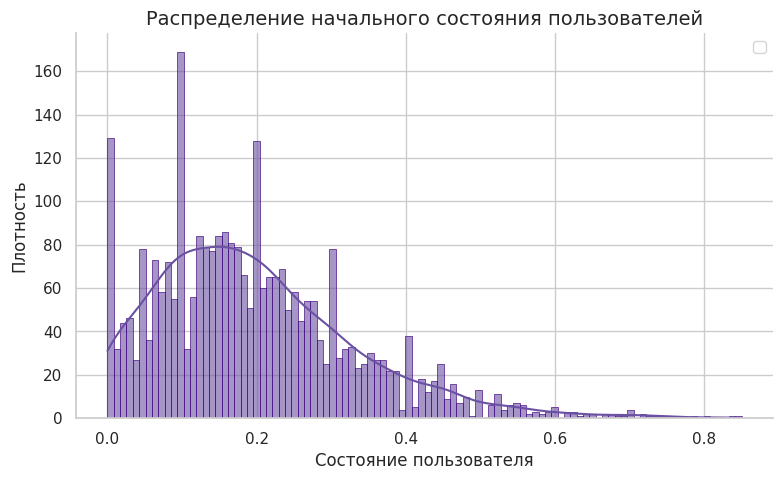

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(9, 5))

sns.histplot(
    user_state['x0'],
    bins=100,
    kde=True,
    color="#6a51a3",          # основной цвет (Purples)
    edgecolor="#3f007d",      # более тёмные границы
    alpha=0.6
)

plt.title("Распределение начального состояния пользователей", fontsize=14)
plt.xlabel("Состояние пользователя")
plt.ylabel("Плотность")

plt.legend()
sns.despine()

plt.show()

эмпирическая вероятность того, что пользователь принимает рекомендации системы

## Продолжение динамики

In [ ]:
full = full.with_columns(
    pl.when(pl.col("action_type") == "order")
    .then(1)
    .otherwise(0)
    .fill_null(0)
    .alias("reaction")
)

In [ ]:
daily = (
    full
    .group_by(["user_id", "date"])
    .agg([
        pl.col("reaction").sum().alias("orders"),
        pl.len().alias("exposures")
    ])
    .with_columns(
        (pl.col("orders") / pl.col("exposures"))
        .fill_null(0)
        .alias("r_t")
    )
    .sort(["user_id", "date"])
)

In [ ]:
daily

user_id,date,orders,exposures,r_t
i64,date,i32,u32,f64
3048,2024-05-10,0,10,0.0
3048,2024-05-11,1,10,0.1
3048,2024-05-13,3,10,0.3
3048,2024-05-15,2,10,0.2
3048,2024-05-16,0,10,0.0
…,…,…,…,…
11181724,2024-07-27,0,10,0.0
11181724,2024-07-28,0,10,0.0
11181724,2024-07-29,2,10,0.2


In [ ]:
alphas = np.arange(0.0, 1., 0.1)

In [ ]:
base_data = (
    daily
    .with_columns(pl.col("date").cast(pl.Utf8))
    .select(["user_id", "date", "r_t"])
    .to_numpy()
)
base_data

array([[3048, '2024-05-10', 0.0],
       [3048, '2024-05-11', 0.1],
       [3048, '2024-05-13', 0.3],
       ...,
       [11181724, '2024-07-29', 0.2],
       [11181724, '2024-07-30', 0.1],
       [11181724, '2024-07-31', 0.3]], dtype=object)

In [ ]:
micro_rows = []
macro_rows = []

In [ ]:
x0_map = dict(zip(user_state["user_id"], user_state["x0"]))

In [ ]:
from collections import defaultdict
from tqdm import tqdm
from scipy.stats import wasserstein_distance

#
Внимание = единица
Всё прошлое влияло больше чем рекомендации

In [ ]:
for alpha in alphas:
    state = defaultdict(lambda: 0.0)

    prev_state = {}

    for user_id, date, r_t in tqdm(
        base_data,
        desc=f"α={alpha:.1f}"
    ):
        prev = state[user_id]
        new = alpha * prev + (1 - alpha) * r_t
        state[user_id] = new

        # =========================
        # MICRO
        # =========================
        if user_id in prev_state:
            micro = abs(new - prev_state[user_id])
        else:
            micro = 0.0

        prev_state[user_id] = new

        micro_rows.append({
            "alpha": alpha,
            "date": date,
            "micro_shift": micro
        })

    # =========================
    # MACRO (Wasserstein)
    # =========================

    x_t = np.array(list(state.values()))
    x_0 = np.array([
        x0_map.get(u, 0.0) for u in state.keys()
    ])

    macro = wasserstein_distance(x_0, x_t)

    macro_rows.append({
        "alpha": alpha,
        "macro_shift": macro
    })

α=0.9: 100%|██████████| 117771/117771 [00:00<00:00, 172602.77it/s]


In [ ]:
micro_acc = defaultdict(list)

for r in micro_rows:
    key = (r["alpha"], r["date"])
    micro_acc[key].append(r["micro_shift"])

In [ ]:
alphas = list(np.arange(0, 1, 0.1))
dates = sorted(set(r["date"] for r in micro_rows))

In [ ]:
a_idx = {a:i for i,a in enumerate(alphas)}
t_idx = {t:i for i,t in enumerate(dates)}

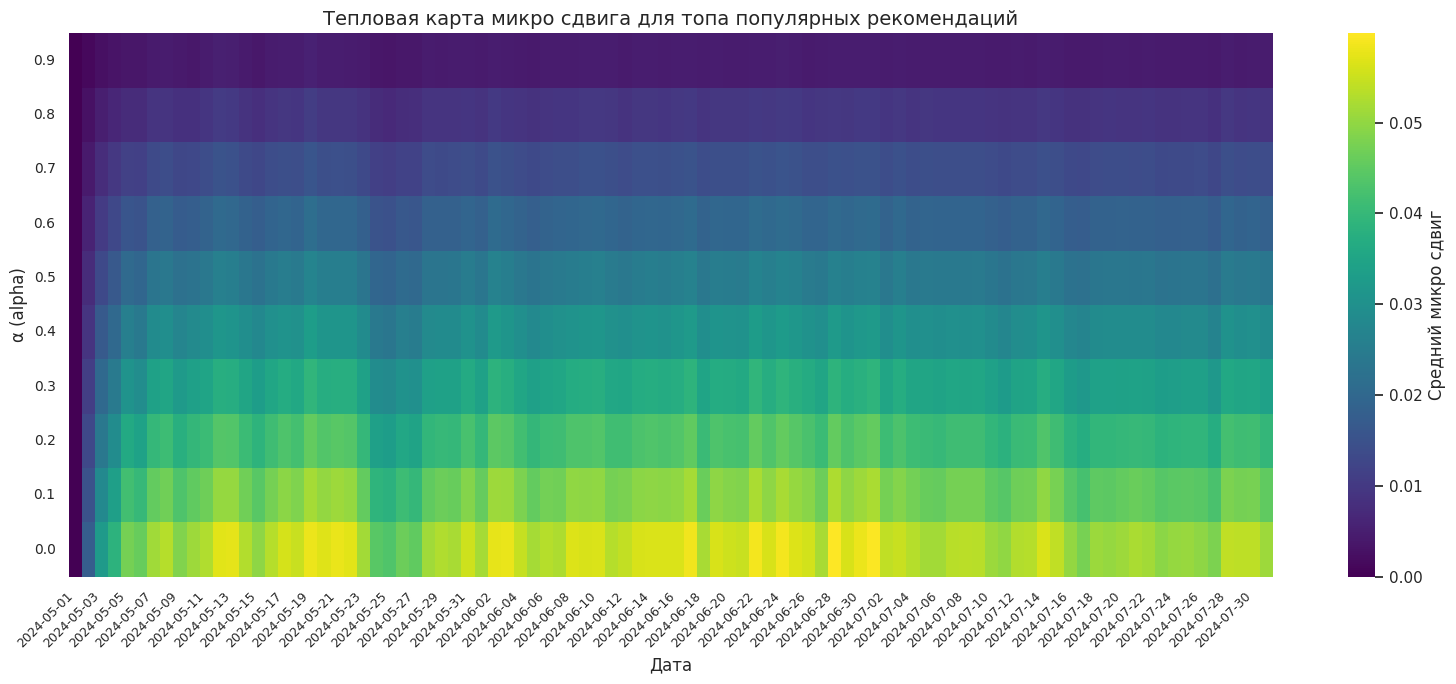

In [ ]:
## tp

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="viridis",
    #vmin=0,        # ✔ нижняя граница
    #vmax=0.08,      # ✔ верхняя граница
    cbar_kws={'label': 'Средний микро сдвиг'},
)

# инверсия оси Y
ax.invert_yaxis()

# читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для топа популярных рекомендаций', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()

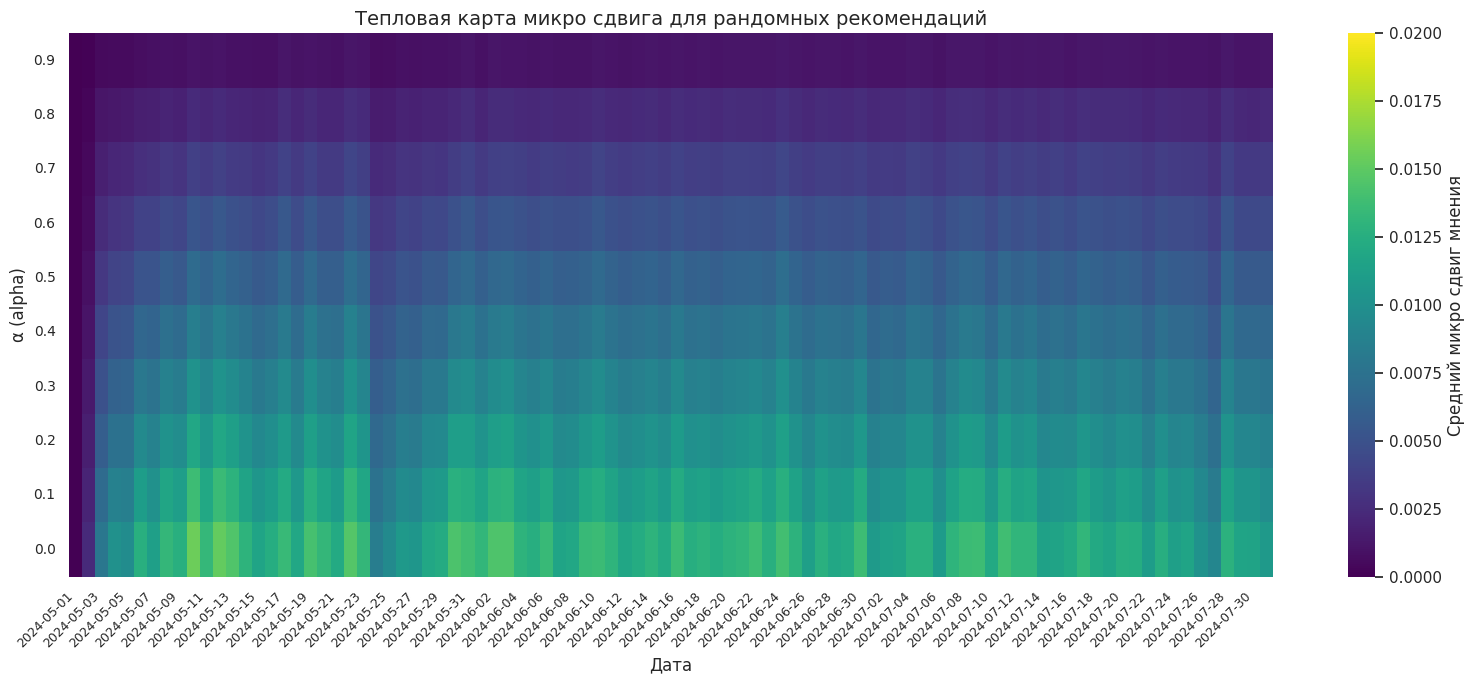

In [ ]:
## rn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="viridis",
    cbar_kws={'label': 'Средний микро сдвиг мнения'},
    vmin=0,
    vmax=0.02,
)

ax.invert_yaxis()

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)


ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для рандомных рекомендаций', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()

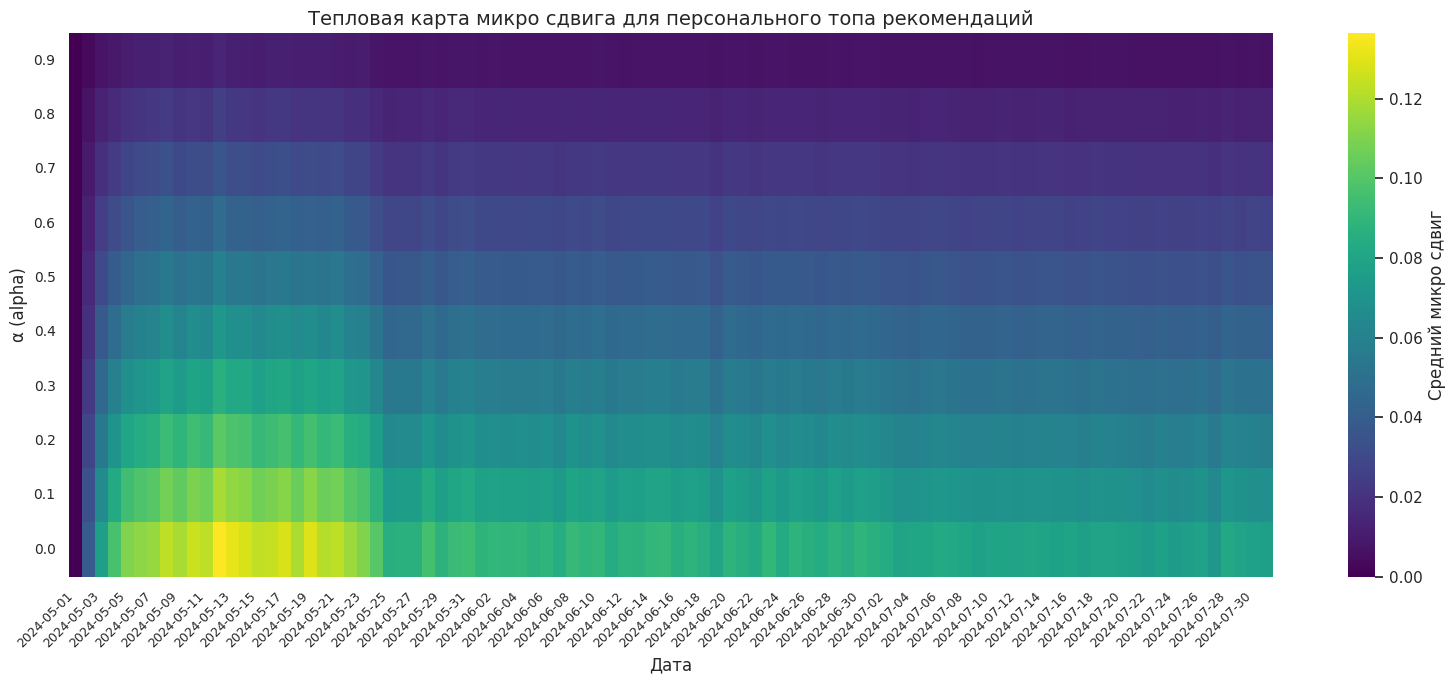

In [ ]:
## personal tp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="viridis",  # ✔ единая палитра
    cbar_kws={'label': 'Средний микро сдвиг'},
)

# ✔ инверсия оси Y
ax.invert_yaxis()

# ✔ читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)


ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для персонального топа рекомендаций', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()

Мнение -- склонность пользователя покупать что-то из того, что ему порекомендовали.

оно реализуется через наблюдаемую поведенческую реакцию пользователя

У нас мнение рассматривается как поведение в рамках конкретной системы рекомендаций



In [ ]:
recommender = rn_uniform

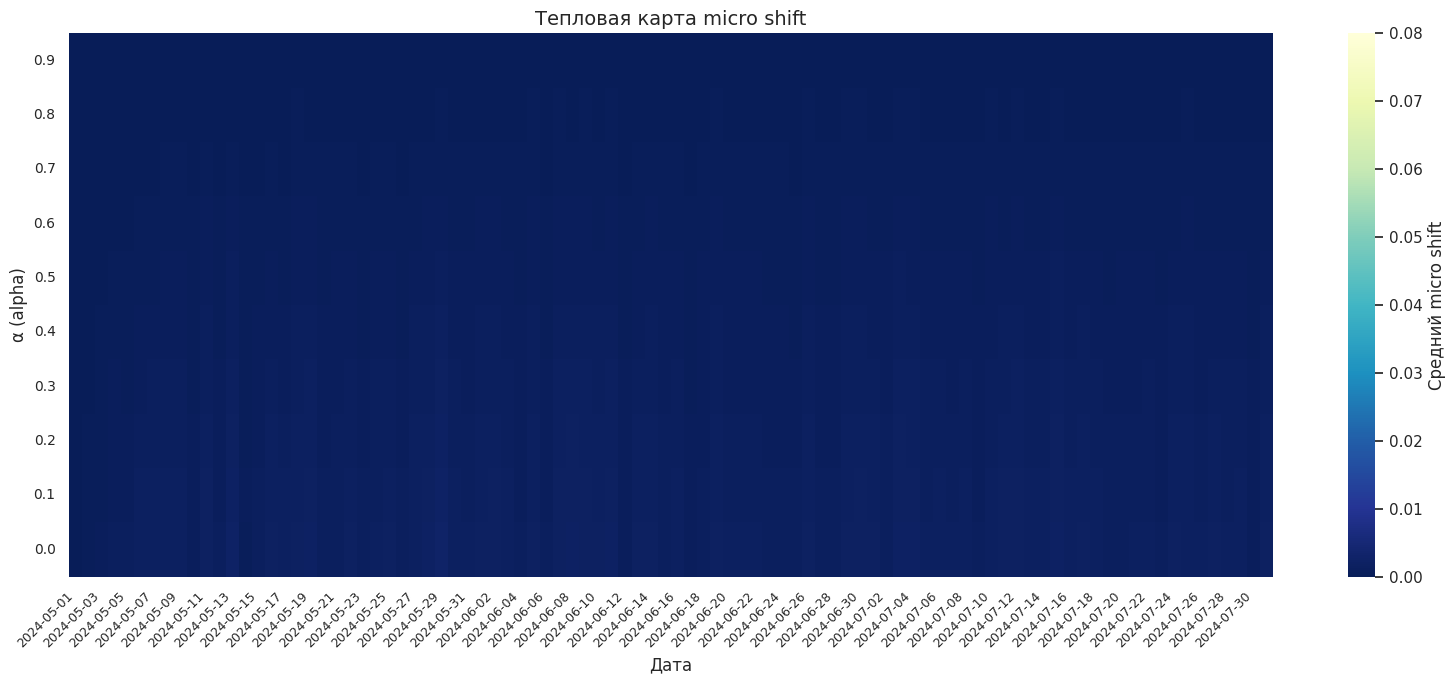

In [ ]:
## rn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="YlGnBu_r",  # ✔ единая палитра
    cbar_kws={'label': 'Средний micro shift'},
     vmin=0,        # ✔ нижняя граница
    vmax=0.08,      # ✔ верхняя граница
)

# ✔ инверсия оси Y
ax.invert_yaxis()

# ✔ читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)


ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта micro shift', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()

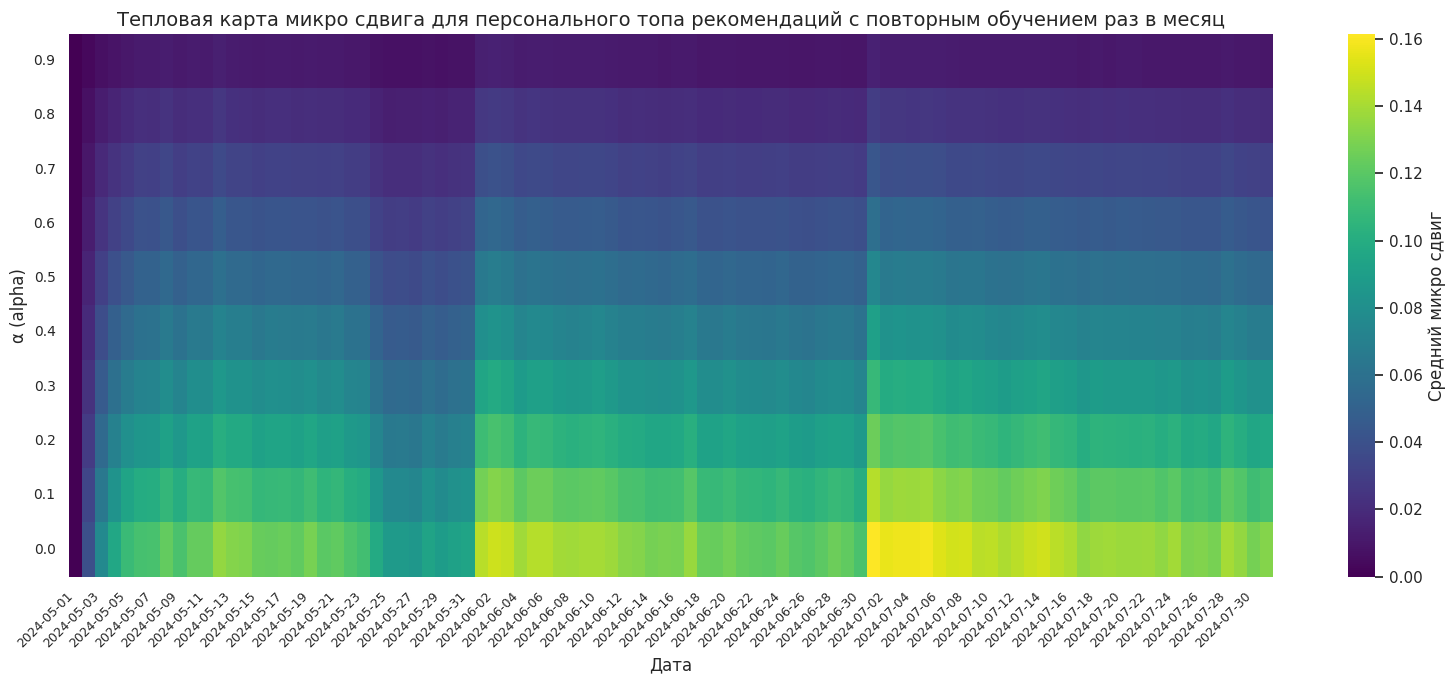

In [ ]:
## personal tp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="Purples")

df = pd.DataFrame(micro_rows)
df['alpha'] = df['alpha'].astype(float).round(1)

# pivot
pivot_df = df.pivot_table(
    index='alpha',
    columns='date',
    values='micro_shift',
    aggfunc='mean'
)

plt.figure(figsize=(16, 7))

ax = sns.heatmap(
    pivot_df,
    cmap="viridis",  # ✔ единая палитра
    cbar_kws={'label': 'Средний микро сдвиг'},
)

# ✔ инверсия оси Y
ax.invert_yaxis()

# ✔ читаемые даты
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=9
)


ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title('Тепловая карта микро сдвига для персонального топа рекомендаций с повторным обучением раз в месяц', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('α (alpha)')

plt.tight_layout()
plt.show()